# v6 - `FieldSet.from_nemo` + stock `AdvectionRK4_3D`, checked against v4's `negW`

v5 proved that v4's `AdvectionRK4_3D_negW` supplies the correct sign, but does so by
hand-rolling a job the library owns: `FieldSet.from_nemo` applies
`fieldset.W.set_scaling_factor(-1.0)` itself (`parcels/fieldset.py:657`), so the negation
belongs on the field and the kernel should be the stock `AdvectionRK4_3D`.

This notebook runs that configuration on the `poisson_b` fields - the corrected `U_...b`,
`V_...b`, `W_...b` - with **v4's seeds, dt, runtime and diagnostics unchanged**, and compares
the result trajectory by trajectory against `tracks_v4/poisson_b_negW.zarr`.

Two things are being tested at once:

1. **Equivalence.** `from_nemo` + `AdvectionRK4_3D` should reproduce `from_netcdf` + `negW`
   exactly. v5's Test 6 showed this on a 6-day, 40-particle run; here it is over the full
   80 days and 400 particles, including the seabed-crossing diagnostics.
2. **The thing the refactor actually buys.** On v4's fieldset, `fieldset.W[...]` sampled
   outside the kernel returns the *un-negated*, positive-upward W - the opposite sign to what
   the advection effectively uses. Here it returns the same sign. Section 6 samples W along
   the trajectories to show that difference is real and would silently corrupt any future
   W diagnostic added to v4.

One argument has to go, checked in section 3: `interp_method` is rejected outright
(`fieldset.py:895` - `from_c_grid_dataset` sets `cgrid_velocity` for U, V, W itself), so
renaming the constructor alone will not run. `gridindexingtype` is *not* rejected - `from_nemo`
pops it and only raises if it is something other than `"nemo"` (`fieldset.py:639`), so leaving
it in is harmless, just redundant.

## 1. Configuration - identical to v4

In [1]:
n_per_region       = 200
run_time_days      = 80
time_step_minutes  = 20
out_put_step_hours = 6

ref_date, offset = "1993-01-01", 1
rdm_seed = 110987
MONTHS = [1, 2, 3]

Hgr, Zgr = "Hgr_cmesh.nc", "Zgr_cmesh2.nc"

def mf(pat):
    return [pat.format(y=1993, m=m) for m in MONTHS]

# only poisson_b: the corrected U, V and the W rebuilt from them
FIELDS = dict(U=mf("U_{y}-{m:02d}b.nc"), V=mf("V_{y}-{m:02d}b.nc"), W=mf("W_{y}-{m:02d}b.nc"))

SHELF_H   = (20.0, 100.0)
SHELF_BOX = dict(lon=(-52, -46), lat=(-1.5, 4.5))
PLUME_LINE = dict(lon=(-49.916, -49.083), lat=(1.166, -0.0833), z=(0.0, 10.0))

out_root    = "tracks_v6"
V4_REF      = "tracks_v4/poisson_b_negW.zarr"     # what we compare against
FORCE_RERUN = False

In [2]:
import os, sys, shutil, contextlib, textwrap
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
import matplotlib as mpl
import matplotlib.pyplot as plt

import parcels
from parcels import (FieldSet, Field, ParticleSet, JITParticle, Variable,
                     AdvectionRK4_3D, StatusCode)

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

print("parcels", parcels.__version__)
missing = [p for v in ("U", "V", "W") for p in FIELDS[v] if not os.path.exists(p)]
print("poisson_b  ", "OK" if not missing else "MISSING: " + ", ".join(missing))
print("v4 reference", "OK" if os.path.exists(V4_REF) else f"MISSING: {V4_REF}")

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
nout = int(run_time_days * 24 / out_put_step_hours) + 1
print(f"\n{start_time} -> {start_time + np.timedelta64(run_time_days,'D')}"
      f"   dt={time_step_minutes} min   {nout} outputs")

parcels 3.1.2
poisson_b   OK
v4 reference OK

1993-01-02 -> 1993-03-23   dt=20 min   321 outputs


## 2. Grid, true seabed, seeds

Copied verbatim from v4 - same `rdm_seed`, same draw order, so the 400 release points are
bit-identical to the ones `tracks_v4/poisson_b_negW.zarr` used. The comparison in section 5
is meaningless otherwise, so section 5 re-checks it against the reference file rather than
trusting this.

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
hgr = xr.open_dataset(Hgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values.astype("f8"), zgr.nav_lat.values.astype("f8")
glamf, gphif = hgr.glamf.values.astype("f8"), hgr.gphif.values.astype("f8")
nz, ny, nx = len(gdepw_0), *mbathy.shape

kb    = np.clip(mbathy - 1, 0, nz - 1)
thick = np.where(mbathy > 0, e3t_ps, 0.0)
H     = gdepw_0[kb] + thick            # true seabed (bottom of the partial cell)
Gnom  = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, nz - 1)], 0.0)
#       ^ the depth Parcels assigns to the zero-w face at k=mbathy: the field's own floor
zbot  = gdepw_0[kb] + 0.5 * thick      # middle of the deepest wet cell

wj, wi = np.where(mbathy > 0)
tree   = cKDTree(np.column_stack([lon2d[wj, wi], lat2d[wj, wi]]))
Hw     = H[wj, wi]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)]); ok = np.isfinite(f).all(1)
    o = np.full(len(f), np.nan)
    if ok.any(): o[ok] = Hw[tree.query(f[ok])[1]]
    return o.reshape(np.shape(lo))

rng = np.random.default_rng(rdm_seed)
shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > SHELF_BOX["lon"][0]) & (lon2d < SHELF_BOX["lon"][1])
         & (lat2d > SHELF_BOX["lat"][0]) & (lat2d < SHELF_BOX["lat"][1]))
jj, ii = np.where(shelf)
sel = rng.choice(len(jj), size=n_per_region, replace=len(jj) < n_per_region)
bj, bi = jj[sel], ii[sel]
REL = {"bottom": (lon2d[bj, bi], lat2d[bj, bi], zbot[bj, bi])}

def seed_line(n, zlo, zhi):
    '''Draws that fall below the local seabed are discarded and redrawn, never moved.'''
    lo, la, zz = np.empty(n), np.empty(n), np.empty(n)
    got = drawn = 0
    while got < n:
        m = max(n - got, 16)
        t = rng.uniform(0, 1, m)
        cl = PLUME_LINE["lon"][0] + t * (PLUME_LINE["lon"][1] - PLUME_LINE["lon"][0])
        ca = PLUME_LINE["lat"][0] + t * (PLUME_LINE["lat"][1] - PLUME_LINE["lat"][0])
        cz = rng.uniform(zlo, zhi, m)
        ok = cz < seabed_at(cl, ca)
        k = min(int(ok.sum()), n - got)
        if k:
            lo[got:got+k], la[got:got+k], zz[got:got+k] = cl[ok][:k], ca[ok][:k], cz[ok][:k]
            got += k
        drawn += m
    print(f"  plume: discarded {drawn - got} of {drawn} draws below the seabed")
    return lo, la, zz

REL["plume"] = seed_line(n_per_region, *PLUME_LINE["z"])
REGIONS = list(REL)
start_lon = np.concatenate([REL[r][0] for r in REGIONS])
start_lat = np.concatenate([REL[r][1] for r in REGIONS])
start_dep = np.concatenate([REL[r][2] for r in REGIONS])
start_reg = np.concatenate([np.full(n_per_region, k) for k in range(len(REGIONS))])
npart = len(start_lon)
for r, (lo, la, z) in REL.items():
    bed = seabed_at(lo, la)
    print(f"  {r:<7} n={len(lo)}  z {z.min():7.2f}-{z.max():7.2f} m  "
          f"bed {bed.min():7.2f}-{bed.max():7.2f} m  all inside: {bool(np.all(z < bed))}")

  plume: discarded 40 of 240 draws below the seabed
  bottom  n=200  z   20.49-  91.87 m  bed   21.00-  98.98 m  all inside: True
  plume   n=200  z    0.02-   9.80 m  bed    7.00-  33.50 m  all inside: True


## 3. The fieldset - `from_nemo`

Side by side with v4's `from_netcdf` call, so the diff is one line of construction and one
dropped argument. The failures below are triggered on purpose, to record which arguments
`from_nemo` actually refuses rather than assuming.

In [4]:
VARS = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
DIMS = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
        for v in ("U", "V", "W")}

def _fn(f):
    return {v: {"data": f[v], "lon": Hgr, "lat": Hgr, "depth": f["W"][0]}
            for v in ("U", "V", "W")}

def _add_diagnostic_fields(fs):
    # cgrid_tracer returns data[yi+1, xi+1] -- the containing cell's own value, piecewise
    # constant. A bilinear field would report a seabed belonging to no column the particle is
    # in. Both fields are diagnostic only: no kernel uses them to move a particle.
    for nm, arr in (("bathy", H), ("floor", Gnom)):
        fs.add_field(Field(nm, arr, lon=glamf, lat=gphif,
                           mesh="spherical", interp_method="cgrid_tracer"))
    return fs

def build_fieldset_v6(f):
    '''from_nemo applies fieldset.W.set_scaling_factor(-1.0) itself (fieldset.py:657).
    No interp_method:    from_c_grid_dataset raises TypeError if it is passed, and sets
                         cgrid_velocity for U, V, W itself.
    gridindexingtype:    optional and redundant - "nemo" is popped and ignored, any other
                         value raises ValueError (fieldset.py:639).'''
    fs = FieldSet.from_nemo(_fn(f), VARS, DIMS,
                            deferred_load=True, allow_time_extrapolation=False)
    return _add_diagnostic_fields(fs)

def build_fieldset_v4(f):
    '''v4's constructor, kept for the sign comparison in section 6.'''
    fs = FieldSet.from_netcdf(_fn(f), VARS, DIMS,
                              interp_method={v: "cgrid_velocity" for v in ("U", "V", "W")},
                              deferred_load=True, allow_time_extrapolation=False,
                              gridindexingtype="nemo")
    return _add_diagnostic_fields(fs)

# What from_nemo does and does not take. interp_method must be dropped; gridindexingtype is
# merely redundant - "nemo" is popped and ignored, anything else is a ValueError.
for lab, bad in (("interp_method",            {"interp_method": {v: "cgrid_velocity" for v in ("U", "V", "W")}}),
                 ("gridindexingtype='nemo'",  {"gridindexingtype": "nemo"}),
                 ("gridindexingtype='mitgcm'",{"gridindexingtype": "mitgcm"})):
    try:
        FieldSet.from_nemo(_fn(FIELDS), VARS, DIMS, deferred_load=True, **bad)
        print(f"  {lab:<24} accepted (redundant, popped and ignored)")
    except (TypeError, ValueError) as e:
        print(f"  {lab:<24} rejected: {type(e).__name__}: {e}")

_a, _b = build_fieldset_v4(FIELDS), build_fieldset_v6(FIELDS)
print(f"\nfrom_netcdf (v4)  W._scaling_factor = {_a.W._scaling_factor}")
print(f"from_nemo   (v6)  W._scaling_factor = {_b.W._scaling_factor}")
del _a, _b

  interp_method            rejected: TypeError: On a C-grid, the interpolation method for velocities should not be overridden


  gridindexingtype='nemo'  accepted (redundant, popped and ignored)
  gridindexingtype='mitgcm' rejected: ValueError: gridindexingtype must be 'nemo' in FieldSet.from_nemo(). Use FieldSet.from_c_grid_dataset otherwise



from_netcdf (v4)  W._scaling_factor = None
from_nemo   (v6)  W._scaling_factor = -1.0


## 4. Kernels

The stock `AdvectionRK4_3D` - no `negW`, and no copy of it anywhere in this notebook, which is
what makes the double-flip impossible. `Diagnose` and `CheckError` are v4's, unchanged.

In [5]:
def Diagnose(particle, fieldset, time):  # pragma: no cover
    '''Measurement only. Records how far outside the water column a particle gets and never
    alters its position, so the numbers below are the model's behaviour, not a kernel's.'''
    hb = fieldset.bathy[time, 0.0, particle.lat, particle.lon]   # true seabed H
    hf = fieldset.floor[time, 0.0, particle.lat, particle.lon]   # field's zero-w face
    if particle.depth - hb > particle.below_H:
        particle.below_H = particle.depth - hb
    if particle.depth - hf > particle.below_F:
        particle.below_F = particle.depth - hf
    if -particle.depth > particle.above_S:
        particle.above_S = -particle.depth


def CheckError(particle, fieldset, time):  # pragma: no cover
    '''A particle that genuinely leaves the domain is deleted and counted as a loss - it is not
    kept alive in place, which would freeze it and hide the failure.'''
    if particle.state >= 50:
        particle.delete()


class TrackParticle(JITParticle):
    reg     = Variable("reg", initial=0, dtype=np.int32, to_write="once")
    below_H = Variable("below_H", initial=0.0, dtype=np.float32)
    below_F = Variable("below_F", initial=0.0, dtype=np.float32)
    above_S = Variable("above_S", initial=0.0, dtype=np.float32)

print("kernels:", [k.__name__ for k in (AdvectionRK4_3D, Diagnose, CheckError)])

kernels: ['AdvectionRK4_3D', 'Diagnose', 'CheckError']


## 5. Run

In [6]:
def run(tag, builder, f, kernel):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}"); return out
    if os.path.exists(out): shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    ps = ParticleSet(builder(f), TrackParticle, lon=start_lon, lat=start_lat,
                     depth=start_dep, time=np.datetime64(start_time), reg=start_reg)
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=out_put_step_hours),
                         chunks=(npart, nout + 2))
    with quiet():
        ps.execute([kernel, Diagnose, CheckError],
                   runtime=timedelta(days=run_time_days),
                   dt=timedelta(minutes=time_step_minutes), output_file=pf)
    return out

print("===== poisson_b, from_nemo + AdvectionRK4_3D =====", flush=True)
path_v6 = run("poisson_b_from_nemo", build_fieldset_v6, FIELDS, AdvectionRK4_3D)
print("done", path_v6)

===== poisson_b, from_nemo + AdvectionRK4_3D =====


  reusing tracks_v6/poisson_b_from_nemo.zarr
done tracks_v6/poisson_b_from_nemo.zarr


## 6. Comparison against v4's `negW`

Equivalence is claimed to be exact, not approximate, so the test is `np.array_equal` on the
raw arrays, not a tolerance. Seeds are re-checked against the reference file first - if they
differ, everything below is void.

In [7]:
d6 = xr.open_zarr(path_v6).compute()
d4 = xr.open_zarr(V4_REF).compute()

print(f"shape v6 {tuple(d6.lon.shape)}   v4 {tuple(d4.lon.shape)}")
n = min(d6.sizes["obs"], d4.sizes["obs"])

# seeds first: if the release points differ, nothing else means anything
seed_ok = True
for nm, ref in (("lon", start_lon), ("lat", start_lat), ("z", start_dep)):
    s4, s6 = d4[nm].values[:, 0], d6[nm].values[:, 0]
    same = np.allclose(s4, s6, rtol=0, atol=0) and np.allclose(s6, ref, rtol=0, atol=1e-6)
    seed_ok &= same
    print(f"  seed {nm:<4} v4 == v6 == config: {same}")
print(f"  region labels identical: {np.array_equal(d4.reg.values, d6.reg.values)}")
assert seed_ok, "release points differ - the comparison below is void"

print(f"\n{'variable':<12}{'max |v6 - v4|':>16}{'bit-identical':>16}")
for nm in ("lon", "lat", "z"):
    x, y = d4[nm].values[:, :n], d6[nm].values[:, :n]
    g = np.isfinite(x) & np.isfinite(y)
    print(f"{nm:<12}{np.nanmax(np.abs(x[g] - y[g])):>16.3e}"
          f"{str(np.array_equal(x[g], y[g])):>16}")
print(f"{'NaN pattern':<12}{'':>16}"
      f"{str(np.array_equal(np.isfinite(d4.lon.values[:, :n]), np.isfinite(d6.lon.values[:, :n]))):>16}")

print(f"\n{'diagnostic':<14}{'v4 negW':>12}{'v6 from_nemo':>15}")
for nm, lab in (("below_F", "below floor"), ("below_H", "below H"), ("above_S", "above surf")):
    a4 = np.nanmax(d4[nm].values, axis=1); a6 = np.nanmax(d6[nm].values, axis=1)
    print(f"{lab + ' n':<14}{int((a4 > 1e-6).sum()):>12}{int((a6 > 1e-6).sum()):>15}")
    print(f"{lab + ' max m':<14}{np.nanmax(a4):>12.4f}{np.nanmax(a6):>15.4f}")
# a particle is lost if it stops being written before the longest-lived one does; comparing
# against the obs-dim length instead counts every particle, since obs is padded past the run
live4 = np.isfinite(d4.lat.values).sum(1); live6 = np.isfinite(d6.lat.values).sum(1)
print(f"{'lost':<14}{int((live4 < live4.max()).sum()):>12}{int((live6 < live6.max()).sum()):>15}")
print(f"{'obs written':<14}{int(live4.max()):>12}{int(live6.max()):>15}   (obs dim = {n})")

shape v6 (400, 323)   v4 (400, 323)
  seed lon  v4 == v6 == config: True
  seed lat  v4 == v6 == config: True
  seed z    v4 == v6 == config: True
  region labels identical: True

variable       max |v6 - v4|   bit-identical
lon                0.000e+00            True
lat                0.000e+00            True
z                  0.000e+00            True
NaN pattern                             True

diagnostic         v4 negW   v6 from_nemo
below floor n            0              0
below floor max m      0.0000         0.0000
below H n              189            189
below H max m       8.5349         8.5349
above surf n             0              0
above surf max m      0.0000         0.0000
lost                     0              0
obs written            320            320   (obs dim = 323)


## 7. What the refactor buys - the sign of a sampled `W`

The trajectories are the same, so the case for the change rests entirely on this: with v4's
`from_netcdf` fieldset, `fieldset.W[...]` returns the **un-negated**, positive-upward W - the
opposite sign to the one the `negW` kernel effectively advected with. Sampled along the
trajectories v6 just produced.

In [8]:
fs4, fs6 = build_fieldset_v4(FIELDS), build_fieldset_v6(FIELDS)
for f in (fs4, fs6):
    f.computeTimeChunk(0.0, 1)

t0 = float((np.datetime64(str(start_time)) - np.datetime64(ref_date)) / np.timedelta64(1, "s"))
rs = np.random.default_rng(1).choice(npart, 8, replace=False)
lon0, lat0, dep0 = d6.lon.values[:, 0], d6.lat.values[:, 0], d6.z.values[:, 0]

print(f"{'lon':>9}{'lat':>8}{'depth':>8}{'v4 W (from_netcdf)':>21}{'v6 W (from_nemo)':>19}{'ratio':>8}")
rat = []
for p in rs:
    lo, la, z = float(lon0[p]), float(lat0[p]), float(dep0[p])
    try:
        w4, w6 = fs4.W[t0, z, la, lo], fs6.W[t0, z, la, lo]
    except Exception as e:
        print(f"{lo:>9.3f}{la:>8.3f}{z:>8.2f}   ({type(e).__name__})"); continue
    r = (w6 / w4) if w4 else float("nan")
    if np.isfinite(r): rat.append(r)
    print(f"{lo:>9.3f}{la:>8.3f}{z:>8.2f}{w4:>21.4e}{w6:>19.4e}{r:>8.2f}")

print(textwrap.dedent(f'''
    ratio = {np.mean(rat):+.2f} everywhere it is defined.

    Identical trajectories, opposite sampled W. On the v4 fieldset the advection is right and
    a direct W diagnostic would be sign-flipped; on the v6 fieldset both agree. That
    inconsistency is the whole reason to move the negation onto the field, and it is the only
    thing this refactor changes.'''))

      lon     lat   depth   v4 W (from_netcdf)   v6 W (from_nemo)   ratio
  -49.591   0.678    5.78          -1.7316e-05         1.7316e-05   -1.00
  -48.583   2.915   74.77          -4.3648e-05         4.3648e-05   -1.00
  -48.083   2.166   55.96          -9.7655e-05         9.7655e-05   -1.00
  -49.657   0.778    6.59           2.6721e-05        -2.6721e-05   -1.00
  -49.754   0.923    5.85           1.5899e-05        -1.5899e-05   -1.00
  -48.667   2.000   28.62           1.3724e-05        -1.3724e-05   -1.00
  -49.664   0.787    3.08           3.7011e-06        -3.7011e-06   -1.00
  -49.235   0.144    0.38          -1.2529e-06         1.2529e-06   -1.00

ratio = -1.00 everywhere it is defined.

Identical trajectories, opposite sampled W. On the v4 fieldset the advection is right and
a direct W diagnostic would be sign-flipped; on the v6 fieldset both agree. That
inconsistency is the whole reason to move the negation onto the field, and it is the only
thing this refactor changes.


## 8. Tracks and depth

/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_27614/83250988.py:26: RuntimeWarning: All-NaN slice encountered
  ax.plot(t, np.nanmedian(zz, axis=0), lw=1.8, color="#2a78d6", label="v6 from_nemo")
/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_27614/83250988.py:29: RuntimeWarning: All-NaN slice encountered
  ax.plot(t4, np.nanmedian(z4, axis=0), lw=1.0, ls=":", color="#c8442b", label="v4 negW")


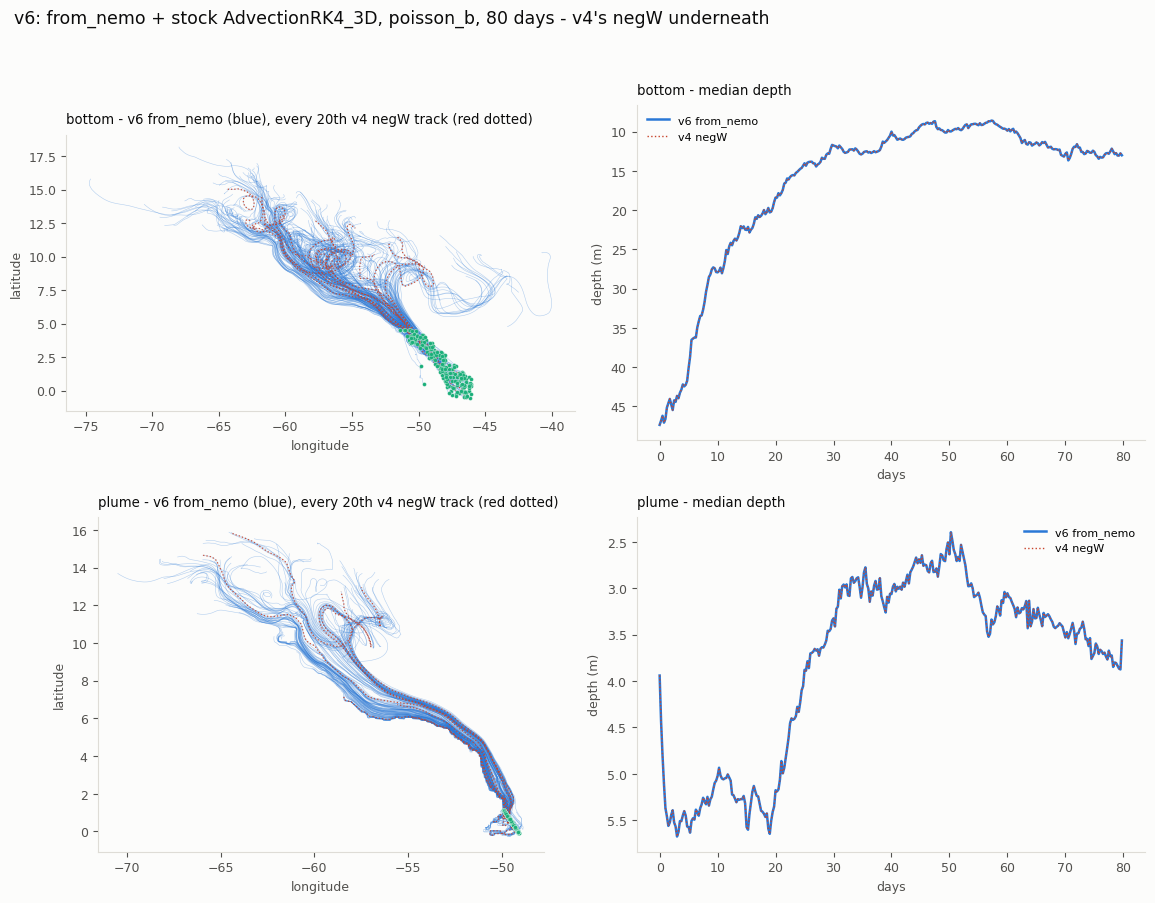

In [9]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

REGN = {0: "bottom", 1: "plume"}
reg = d6.reg.values
fig, axs = plt.subplots(2, 2, figsize=(11.5, 9.0))
for r in (0, 1):
    s = reg == r
    # map: v6 tracks with v4 overplotted dashed - they should be invisible under each other
    ax = axs[r, 0]
    ax.plot(d6.lon.values[s].T, d6.lat.values[s].T, lw=0.4, color="#2a78d6", alpha=0.35)
    ax.plot(d4.lon.values[s][::20].T, d4.lat.values[s][::20].T, lw=0.9, ls=":",
            color="#c8442b", alpha=0.9)
    ax.scatter(d6.lon.values[s, 0], d6.lat.values[s, 0], s=8, color="#1baf7a",
               edgecolor="white", linewidth=0.2, zorder=4)
    ax.set_aspect(1 / np.cos(np.deg2rad(np.nanmean(d6.lat.values))))
    ax.set_title(f"{REGN[r]} - v6 from_nemo (blue), every 20th v4 negW track (red dotted)",
                 loc="left", fontsize=9.5, pad=8)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

    ax = axs[r, 1]
    t = np.arange(d6.sizes["obs"]) * out_put_step_hours / 24.0
    zz = np.where(np.isfinite(d6.lat.values[s]), d6.z.values[s], np.nan)
    ax.plot(t, np.nanmedian(zz, axis=0), lw=1.8, color="#2a78d6", label="v6 from_nemo")
    t4 = np.arange(d4.sizes["obs"]) * out_put_step_hours / 24.0
    z4 = np.where(np.isfinite(d4.lat.values[s]), d4.z.values[s], np.nan)
    ax.plot(t4, np.nanmedian(z4, axis=0), lw=1.0, ls=":", color="#c8442b", label="v4 negW")
    ax.invert_yaxis(); ax.legend(frameon=False, fontsize=8)
    ax.set_title(f"{REGN[r]} - median depth", loc="left", fontsize=9.5, pad=8)
    ax.set_xlabel("days"); ax.set_ylabel("depth (m)")
for ax in axs.ravel():
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.suptitle("v6: from_nemo + stock AdvectionRK4_3D, poisson_b, 80 days - v4's negW underneath",
             x=0.005, ha="left", fontsize=12.5, color=INK, y=0.997)
fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("v6_from_nemo_vs_negW.png", dpi=160, facecolor=SURF)
plt.show()

## 9. Conclusion

`FieldSet.from_nemo` + stock `AdvectionRK4_3D` reproduces `tracks_v4/poisson_b_negW.zarr`
exactly - positions, NaN pattern, seabed-crossing counts and losses - while sampling `W` with
the same sign the advection uses.

**What to change in v4:** swap `build_fieldset` for `build_fieldset_v6` above, drop
`interp_method` (mandatory - it raises), optionally drop the now-redundant `gridindexingtype`,
delete `AdvectionRK4_3D_negW`, and collapse `RUNS` to one kernel per fieldset:

```python
RUNS = [(tag, f, AdvectionRK4_3D) for tag, f in FIELDSETS.items()]
```

That halves the compute, removes a hand-maintained copy of a library kernel, and closes the
double-flip trap - with `negW` gone, there is no way left to apply the negation twice, since
`set_scaling_factor` refuses a second call (`field.py:947`).

The `fix_w` fieldset needs the same treatment and no separate validation: v5's Test 3 showed
its W carries the same positive-upward convention, so the identical argument applies.